In [3]:
from ipywidgets import widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas_profiling import ProfileReport
from pandas_profiling.utils.cache import cache_file

input_path = '/home/muody/data/kaggle/titanic/'
train = pd.read_csv(input_path + 'train.csv')
X_test = pd.read_csv(input_path + 'test.csv')
y_test = pd.read_csv(input_path + 'gender_submission.csv')
! ls /home/muody/data/kaggle/titanic

gender_submission.csv  test.csv  train.csv


# EDA
* Variable Identification
* Univariate Analysis
* Bi-variate Analysis
* Missing values treatment
* Outlier treatment
* Variable transformation
* Variable creation

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [254]:
# Outliers
Q1 = train.quantile(0.25)
Q3 = train.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = 1.5
mask = ((train < (Q1 - outlier_threshold * IQR)) | (train > (Q3 + outlier_threshold * IQR)))

mask.sum()

Age             11
Cabin            0
Embarked         0
Fare           116
Name             0
Parch          213
PassengerId      0
Pclass           0
Sex              0
SibSp           46
Survived         0
Ticket           0
dtype: int64

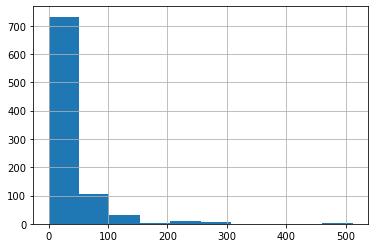

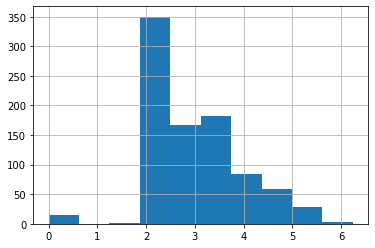

In [274]:
train['Fare'].skew()
train['Fare'].kurtosis()

np.log(train['Fare']+1).skew()
np.log(train['Fare']+1).kurtosis()

train['Fare'].hist()
plt.show()
np.log(train['Fare']+1).hist()
plt.show()

In [200]:
# Generate the Profiling Report
profile = ProfileReport(
    df,
    title="Titanic Dataset",
    html={"style": {"full_width": True}},
    sort="None",
    explorative=True
)
# The Notebook Widgets Interface
profile.to_widgets()

In [ ]:
# Generate the Profiling Report
profile = ProfileReport(
    df,
    title="Titanic Dataset",
    html={"style": {"full_width": True}},
    sort="None",
    explorative=True
)
# The Notebook Widgets Interface
profile.to_widgets()

# Variable Identification

In [33]:
categorical = ['Sex', 'Ticket', 'Cabin', 'Embarked']
continuous = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
target = ['Survived']

# Issues
missingness =  ['Embarked', 'Cabin', 'Age']
zeros = ['SibSp', 'Parch', 'Fare']
outliers = ['Age']
high_cardinality = ['Ticket', 'Cabin']
skewed = ['Parch', 'Fare', 'SibSp']
uniques = ['Name']
strings = ['Name', 'Embarked', 'Cabin']

# Issues
mulitcollinearity = {
    'Pclass': 'Fair',
    'Pclass': 'Age'
}

# Preprocessing 

In [234]:
from sklearn.model_selection import train_test_split

train = pd.read_csv(input_path + 'train.csv')
#train = train[mask['Fare'] == False]
df[mask[]]
X = train.drop(target, axis=1)
y = train[target].values.ravel()
test = pd.read_csv(input_path + 'test.csv')
test_ID = test['PassengerId']
# Outliers Treatment
# train[mask] = np.nan
# Transformations

# Feature Engineering
def feature_engineering(df):
    df['Fare'] = np.log(df['Fare'] + 1)
    df['SibSp'] = np.log(df['SibSp'] + 1)
    df['Parch'] = np.log(df['Parch'] + 1)
    df['Ticket'] = df['Ticket'].str.replace(' ', '').str.replace('.', '').str.extract('(\d+)')
    df['Ticket'] = df['Ticket'].astype('float64')
    #title = pd.Series([i.split(",")[1].split(".")[0].strip() for i in train["Name"]])
    #title = title.replace(['Lady', 'the Countess','Countess','Capt', 
    #                       'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    #df['Title'] = title
    #df = df.join(df['Title'].str.get_dummies())
    df['Cabin'] = df['Cabin'].str.extract('([^a-z])(\d)')[0]
    #df['Cabin'] = df['Cabin'].astype('category').cat.codes.astype('int64')
    df['Sex'] = df['Sex'].astype('category').cat.codes.astype('int64')
    df['Pclass'] = df['Pclass'].astype('category').cat.codes.astype('int64')
    df = df.drop(columns={'PassengerId', 'Name'})
    df = df.fillna(np.nan)
    return df

#for col in skewed:
#    print(df[col].kurtosis(), train[col].kurtosis())
#    print(df[col].skew(), train[col].skew())

X = feature_engineering(X)
test = feature_engineering(test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,2,1,22.0,0.693147,0.000000,521171.0,2.110213,NaN,S
1,0,0,38.0,0.693147,0.000000,17599.0,4.280593,C,C
2,2,0,26.0,0.000000,0.000000,23101282.0,2.188856,NaN,S
3,0,0,35.0,0.693147,0.000000,113803.0,3.990834,C,S
4,2,1,35.0,0.000000,0.000000,373450.0,2.202765,NaN,S
...,...,...,...,...,...,...,...,...,...
886,1,1,27.0,0.000000,0.000000,211536.0,2.639057,NaN,S
887,0,0,19.0,0.000000,0.000000,112053.0,3.433987,B,S
888,2,0,NaN,0.693147,1.098612,6607.0,3.196630,NaN,S
889,0,1,26.0,0.000000,0.000000,111369.0,3.433987,C,C


In [235]:
X['Title'].str.get_dummies()

KeyError: 'Title'

In [238]:
# importing libraries 
def logreg():
    import statsmodels.api as sm
    import pandas as pd  

    #X = train.fillna(999).drop(target, axis=1)#.values
    #y = train.fillna(999)[target]#.values#.ravel()
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # building the model and fitting the data 
    log_reg = sm.Logit(y_train, X_train).fit()

    # performing predictions on the test datdaset 
    y_pred = log_reg.predict(X_test)
    y_pred = y_pred > .5
    print('\n','Classification Report\n', classification_report(y_test, y_pred))

    log_reg.summary()

# SKLEARN PIPELINE

In [239]:
# Transformerations
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    #('pca', PCA(n_components=4)),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=None)),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),

])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),])

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced_subsample')),])

scores = cross_val_score(rf, X, y, cv=5)
print("cv_avg:", np.mean(scores))
print("cv_all:", scores)

rf.fit(X_train, y_train)
print("train: ", rf.score(X_train, y_train))
print("test:  ", rf.score(X_test, y_test))

y_pred = rf.predict(X_test)
print('\n','Classification Report\n', classification_report(y_test, y_pred))

cv_avg: 0.832772581758835
cv_all: [0.83240223 0.78651685 0.84831461 0.8258427  0.87078652]
train:  0.9971910112359551
test:   0.8547486033519553

 Classification Report
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       114
           1       0.82      0.77      0.79        65

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



In [240]:
#rf.steps[1][1].feature_importances_
onehot_columns = list(rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names(input_features=categorical_features))
numeric_features_list = list(numeric_features)
numeric_features_list.extend(onehot_columns)

import eli5
eli5.explain_weights(rf.named_steps['classifier'], top=100, feature_names=numeric_features_list)

Weight,Feature
0.2192 ± 0.1304,Sex
0.2190 ± 0.1031,Ticket
0.1668 ± 0.1005,Fare
0.1654 ± 0.0681,Age
0.0520 ± 0.0739,Pclass
0.0389 ± 0.0313,SibSp
0.0361 ± 0.0661,Cabin_missing_value
0.0324 ± 0.0274,Parch
0.0165 ± 0.0267,Embarked_S
0.0111 ± 0.0178,Embarked_C


# Model Selection

In [241]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
kfold = StratifiedKFold(n_splits=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

classifiers = [
    KNeighborsClassifier(),
    SVC(probability=True),
    NuSVC(probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    AdaBoostClassifier(),
    GradientBoostingClassifier(),
    LogisticRegression(),
    ExtraTreesClassifier(),
    #LinearDiscriminantAnalysis(),
    ]
for classifier in classifiers:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', classifier)])
    print(classifier)
    print("cv score: %.3f" % round(np.mean(cross_val_score(pipe, X, y, cv=10)),3))

KNeighborsClassifier()
cv score: 0.819
SVC(probability=True)
cv score: 0.820
NuSVC(probability=True)
cv score: 0.818
DecisionTreeClassifier()
cv score: 0.773
RandomForestClassifier()
cv score: 0.836
AdaBoostClassifier()
cv score: 0.808
GradientBoostingClassifier()
cv score: 0.834
LogisticRegression()
cv score: 0.794
ExtraTreesClassifier()
cv score: 0.814


In [242]:
# Random forest tuning
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier()),])


param_grid = {
    #'preprocessor__num__pca__n_components': [1,2,3,4,5],
    'classifier__n_estimators': [200, 500],
    'classifier__max_features': ['auto', 'sqrt', 'log2'],
    'classifier__max_depth' : [10, 50],
    'classifier__criterion' :['gini', 'entropy'],
    'classifier__class_weight': ['balanced_subsample']
}


rf_GS = GridSearchCV(rf, param_grid, cv=kfold, n_jobs=4)
rf_GS.fit(X, y)
rf_BEST = rf_GS.best_estimator_

# Best score
print(rf_GS.best_params_)
print(rf_GS.best_score_)

{'classifier__class_weight': 'balanced_subsample', 'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__max_features': 'auto', 'classifier__n_estimators': 500}
0.8462421972534333


In [243]:
# Adaboost
DTC = DecisionTreeClassifier()

adaDTC = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(DTC, random_state=7)),])

param_grid = {
    "classifier__base_estimator__criterion" : ["gini", "entropy"],
    "classifier__base_estimator__splitter" :   ["best", "random"],
    "classifier__algorithm" : ["SAMME","SAMME.R"],
    "classifier__n_estimators" :[1,2],
    "classifier__learning_rate":  [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3,1.5]}


ada_GS = GridSearchCV(adaDTC, param_grid, cv=kfold, n_jobs=4)
ada_GS.fit(X, y)  
ada_BEST = ada_GS.best_estimator_ 

# Best score
print(ada_GS.best_params_)
print(ada_GS.best_score_)

{'classifier__algorithm': 'SAMME.R', 'classifier__base_estimator__criterion': 'entropy', 'classifier__base_estimator__splitter': 'best', 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 2}
0.8024594257178526


In [244]:
#SVC Tuning
svc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', NuSVC(probability=True)),])


param_grid = {
    'classifier__kernel': ['rbf'], 
    'classifier__gamma': [ 0.001, 0.01, 0.1, 1],
    #'classifier__C': [0.25, 0.5, 1, 10, 50, 100, 200, 300, 1000]
}


svc_GS = GridSearchCV(svc,param_grid, cv=kfold, scoring="accuracy", n_jobs=4)
svc_GS.fit(X, y)
svc_BEST = svc_GS.best_estimator_

# Best score
print(svc_GS.best_params_)
print(svc_GS.best_score_)

{'classifier__gamma': 1, 'classifier__kernel': 'rbf'}
0.8159800249687891


In [245]:
# Gradient boosting tuning
gbc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('gbc', GradientBoostingClassifier()),])

param_grid = {'gbc__loss' : ["deviance"],
              'gbc__n_estimators' : [100,200],
              'gbc__learning_rate': [0.1, 0.05, 0.01],
              'gbc__max_depth': [4, 8, 16, 32, 64],
              'gbc__min_samples_leaf': [50,100],
              'gbc__max_features': [0.3, 0.1] 
              }


gbc_GS = GridSearchCV(gbc, param_grid, scoring="accuracy", n_jobs=4)
gbc_GS.fit(X, y)
gbc_BEST = gbc_GS.best_estimator_

# Best score
print(gbc_GS.best_params_)
print(gbc_GS.best_score_)

{'gbc__learning_rate': 0.1, 'gbc__loss': 'deviance', 'gbc__max_depth': 16, 'gbc__max_features': 0.3, 'gbc__min_samples_leaf': 50, 'gbc__n_estimators': 100}
0.8372481325717155


In [246]:
kn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic', KNeighborsClassifier()),])

param_grid = {
    #'pca__n_components': [5, 15, 30, 45, 64],
    #'logistic__C': np.logspace(-4, 4, 4),
}


kn_GS = GridSearchCV(kn, param_grid, cv=kfold, n_jobs=1)
kn_GS.fit(X, y)  
kn_BEST = kn_GS.best_estimator_ 

# Best score
print(kn_GS.best_params_)
print(kn_GS.best_score_)

{}
0.8193383270911362


In [252]:
from sklearn.ensemble import VotingClassifier
votingC = VotingClassifier(
    estimators=[('rf', rf_BEST), ('gbc', gbc_BEST), ('kn', kn_BEST), ('ada', ada_BEST), ('svc', svc_BEST)],
    voting='soft',
    n_jobs=4)
votingC = votingC.fit(X, y)
#print(votingC.score(X_train, y_train))250
#print(votingC.score(X_test, y_test))

In [253]:
test_Survived = pd.Series(votingC.predict(test), name="Survived")
results = pd.concat([test_ID,test_Survived],axis=1)
results.to_csv("ensemble_python_voting.csv",index=False)